## 0. Download and prepare the Kaggle dataset

The raw dataset is downloaded from Kaggle with the CLI and filtered to the four required composers. The helper script `src/prepare_dataset.py` creates reproducible train/dev/test splits and writes a `manifest.json`.


In [1]:
import subprocess
import sys
from pathlib import Path

# Resolve paths relative to this notebook. The repository root is two levels up.
REPO_DIR = Path.cwd()
if REPO_DIR.name == 'notebooks':
    REPO_DIR = REPO_DIR.parent
prepare_script = REPO_DIR / 'src' / 'prepare_dataset.py'

# Download from Kaggle and build train/dev/test splits for the four composers.
# This requires ~/.kaggle/kaggle.json to be configured.
# The filtered dataset is written to ../dataset/midi_classic_music_filtered.
result = subprocess.run(
    [sys.executable, str(prepare_script)],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Source directory already exists: /Users/marston.ward/Documents/AAI-511/final-project/dataset/midiclassics

Dataset inventory:
--------------------------------------------------
Bach          train:  717  dev:  154  test:  153  total: 1024
Beethoven     train:  149  dev:   32  test:   32  total:  213
Chopin        train:   95  dev:   20  test:   21  total:  136
Mozart        train:  180  dev:   39  test:   38  total:  257
--------------------------------------------------
Total                                         1630



# Composer Identification — Exploratory Data Analysis

Exploring the MIDI dataset for the AAI-511 final project before building
LSTM and CNN classification models.

**Dataset:** Kaggle *MIDI Classic Music* (Blanderbuss, 2025), filtered to four composers
**Composers:** Bach · Beethoven · Chopin · Mozart
**Source library:** `pretty_midi`
**Task:** Four-way composer classification from symbolic MIDI files


In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
%matplotlib inline


In [4]:
# Use paths relative to the notebook location so it is portable across machines.
REPO_DIR    = Path.cwd()
if REPO_DIR.name == 'notebooks':
    REPO_DIR = REPO_DIR.parent
DATA_ROOT   = REPO_DIR.parent / 'dataset' / 'midi_classic_music_filtered'
FIGURES_DIR = REPO_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

SPLITS    = ['train', 'dev', 'test']
COMPOSERS = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

print(f'Composers ({len(COMPOSERS)}): {COMPOSERS}')
print(f'Splits   : {SPLITS}')
print(f'Data root exists: {DATA_ROOT.exists()}')


Composers (4): ['Bach', 'Beethoven', 'Chopin', 'Mozart']
Splits   : ['train', 'dev', 'test']
Data root exists: True


## 1. Dataset Overview

In [5]:
rows = []
for split in SPLITS:
    for composer in COMPOSERS:
        folder = DATA_ROOT / split / composer
        files = sorted(set(
            p for pattern in ('*.mid', '*.MID', '*.midi', '*.MIDI')
            for p in folder.glob(pattern)
        ))
        rows.append({'split': split, 'composer': composer, 'count': len(files)})

inv   = pd.DataFrame(rows)
pivot = inv.pivot(index='composer', columns='split', values='count')[['train', 'dev', 'test']]
pivot.columns.name = None
pivot['total'] = pivot.sum(axis=1)

print(f'Total MIDI files: {pivot["total"].sum()}')
print()
pivot


Total MIDI files: 1630



,train,dev,test,total
composer,,,,
Bach,717,154,153,1024
Beethoven,149,32,32,213
Chopin,95,20,21,136
Mozart,180,39,38,257


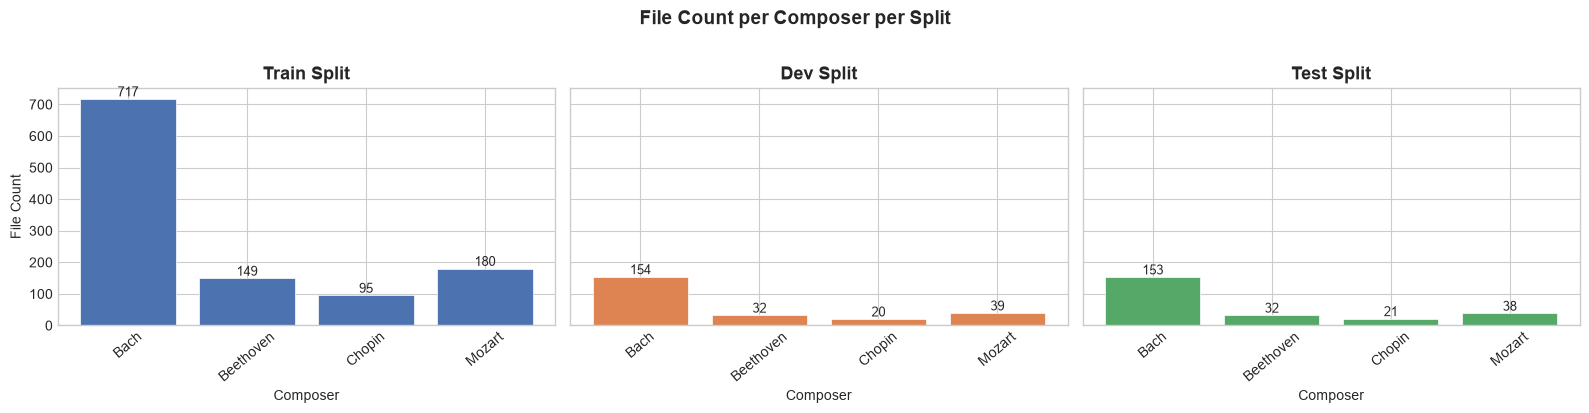

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
colors = {'train': '#4C72B0', 'dev': '#DD8452', 'test': '#55A868'}

for ax, split in zip(axes, SPLITS):
    data = inv[inv['split'] == split].set_index('composer')['count']
    bars = ax.bar(data.index, data.values,
                  color=colors[split], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{split.capitalize()} Split', fontsize=13, fontweight='bold')
    ax.set_xlabel('Composer')
    if split == 'train':
        ax.set_ylabel('File Count')
    ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15, str(val),
                ha='center', va='bottom', fontsize=9)

plt.suptitle('File Count per Composer per Split',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Feature Extraction

Parse every MIDI file with `pretty_midi` to build a metadata DataFrame.


In [7]:
records = []
errors  = []

for split in SPLITS:
    for composer in COMPOSERS:
        folder = DATA_ROOT / split / composer
        midi_paths = sorted(set(
            p for pattern in ('*.mid', '*.MID', '*.midi', '*.MIDI')
            for p in folder.glob(pattern)
        ))
        for midi_path in midi_paths:
            try:
                pm = pretty_midi.PrettyMIDI(str(midi_path))

                duration  = pm.get_end_time()
                _, tempos = pm.get_tempo_changes()
                avg_tempo = float(np.mean(tempos)) if len(tempos) else 120.0
                n_tracks  = len(pm.instruments)

                all_notes  = [n for inst in pm.instruments
                              if not inst.is_drum for n in inst.notes]
                n_notes    = len(all_notes)
                pitches    = [n.pitch    for n in all_notes]
                velocities = [n.velocity for n in all_notes]
                note_durs  = [n.end - n.start for n in all_notes]

                records.append({
                    'split':           split,
                    'composer':        composer,
                    'file':            midi_path.name,
                    'file_size_kb':    midi_path.stat().st_size / 1024,
                    'duration_s':      duration,
                    'avg_tempo_bpm':   avg_tempo,
                    'n_tracks':        n_tracks,
                    'n_notes':         n_notes,
                    'mean_pitch':      np.mean(pitches)          if pitches    else np.nan,
                    'min_pitch':       float(min(pitches))       if pitches    else np.nan,
                    'max_pitch':       float(max(pitches))       if pitches    else np.nan,
                    'pitch_range':     max(pitches)-min(pitches) if pitches    else np.nan,
                    'mean_velocity':   np.mean(velocities)       if velocities else np.nan,
                    'mean_note_dur_s': np.mean(note_durs)        if note_durs  else np.nan,
                    'note_density':    n_notes / duration        if duration > 0 else np.nan,
                })
            except Exception as e:
                errors.append({'file': midi_path.name, 'error': str(e)})

df = pd.DataFrame(records)
print(f'Parsed : {len(df)} files   |   Errors: {len(errors)}')
if errors:
    for err in errors[:10]:
        print(f'  {err}')
df.head(3)


Parsed : 1628 files   |   Errors: 2
  {'file': 'K281 Piano Sonata n03 3mov.mid', 'error': 'Could not decode key with 2 flats and mode 2'}
  {'file': 'Anhang 14-3.mid', 'error': 'Could not decode key with 3 flats and mode 255'}


,split,composer,file,file_size_kb,duration_s,avg_tempo_bpm,n_tracks,n_notes,mean_pitch,min_pitch,max_pitch,pitch_range,mean_velocity,mean_note_dur_s,note_density
0,train,Bach,003706b_.mid,2.833008,46.956456,92.000129,4,304,60.944079,45.0,76.0,31,96.0,0.592104,6.474083
1,train,Bach,003806b_.mid,2.380859,45.000000,96.000000,4,253,60.992095,38.0,74.0,36,96.0,0.711462,5.622222
2,train,Bach,003907bv.mid,2.662109,42.500000,96.000000,4,285,59.182456,40.0,76.0,36,96.0,0.596491,6.705882


## 3. Duration Distribution

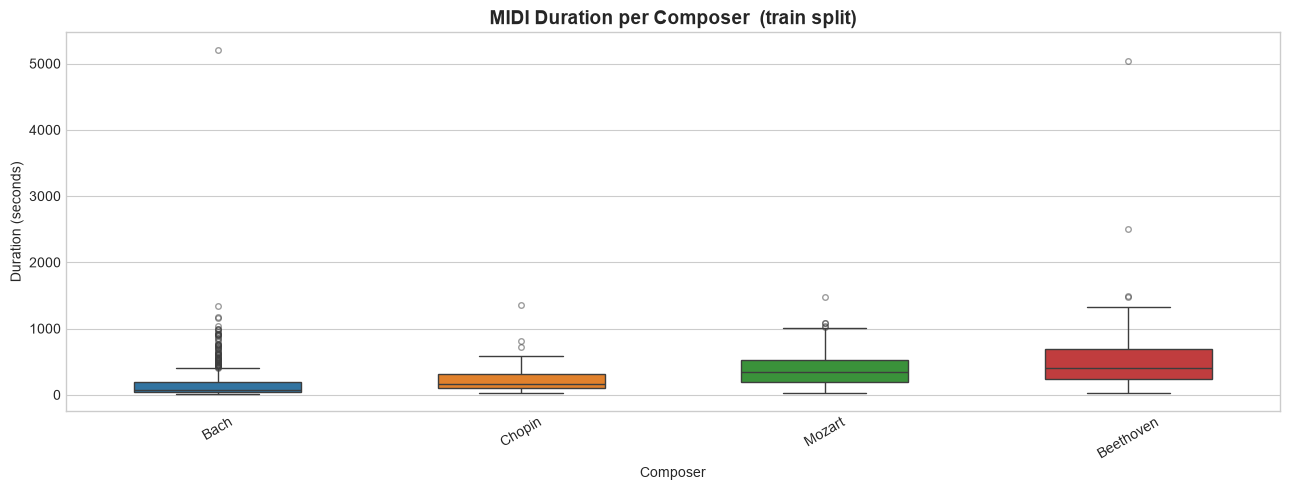

           count   mean    std   min    50%     max
composer                                           
Bach       717.0  160.0  270.5  17.5   75.2  5209.3
Beethoven  149.0  529.0  527.4  27.0  410.4  5032.3
Chopin      95.0  223.8  193.4  23.3  165.6  1352.7
Mozart     179.0  393.5  261.9  26.1  347.5  1478.1


In [8]:
train = df[df['split'] == 'train'].copy()

fig, ax = plt.subplots(figsize=(13, 5))
order = train.groupby('composer')['duration_s'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='duration_s', order=order,
            palette='tab10', ax=ax, width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
ax.set_title('MIDI Duration per Composer  (train split)', fontsize=14, fontweight='bold')
ax.set_xlabel('Composer')
ax.set_ylabel('Duration (seconds)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'duration.png', dpi=150, bbox_inches='tight')
plt.show()

print(train.groupby('composer')['duration_s']
          .describe()[['count', 'mean', 'std', 'min', '50%', 'max']]
          .round(1).to_string())


## 4. Tempo and Track Count

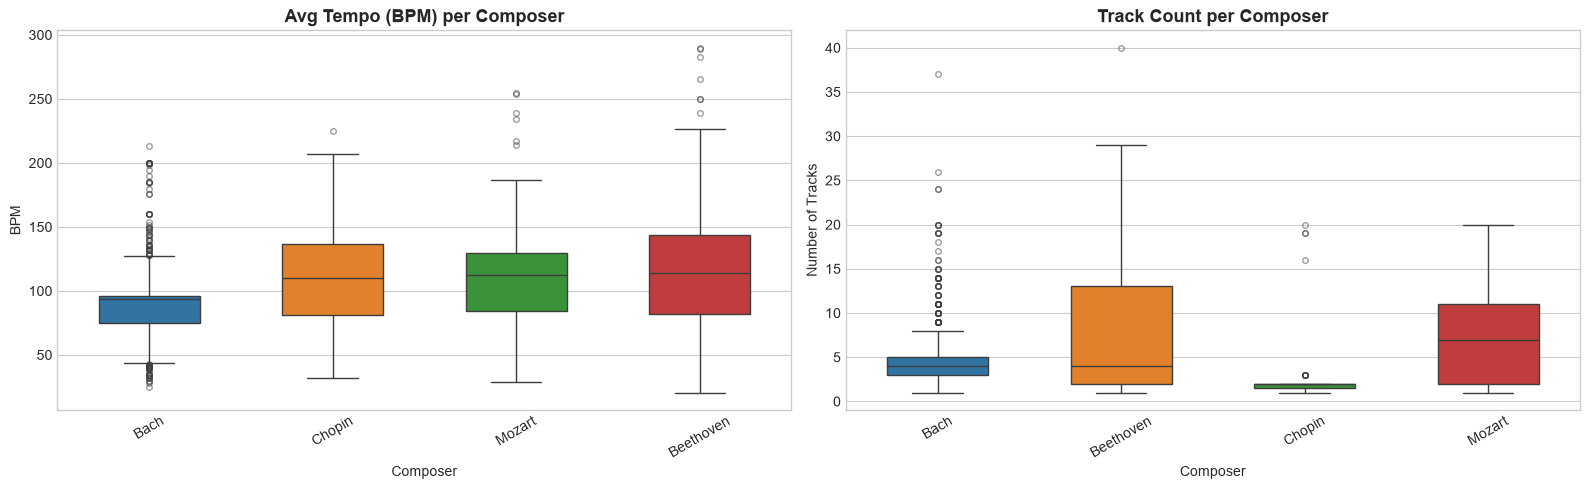

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_t = train.groupby('composer')['avg_tempo_bpm'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='avg_tempo_bpm', order=order_t,
            palette='tab10', ax=axes[0], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Avg Tempo (BPM) per Composer', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Composer')
axes[0].set_ylabel('BPM')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=train, x='composer', y='n_tracks',
            palette='tab10', ax=axes[1], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].set_title('Track Count per Composer', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Composer')
axes[1].set_ylabel('Number of Tracks')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tempo_tracks.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Note Count and Density

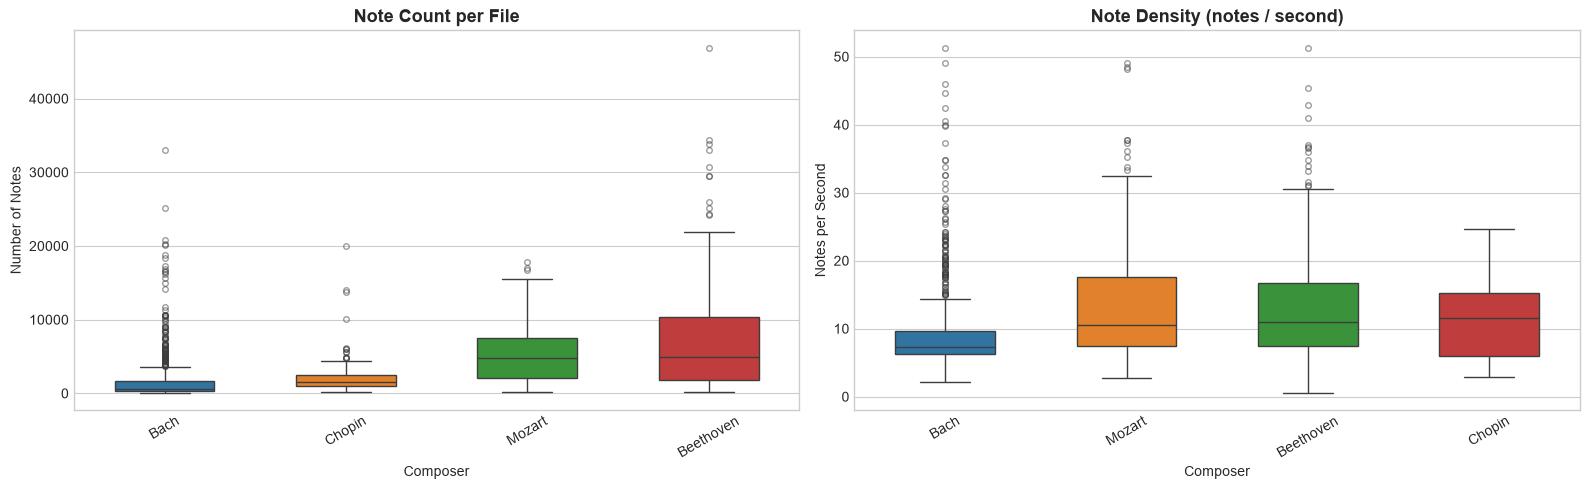

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_n = train.groupby('composer')['n_notes'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='n_notes', order=order_n,
            palette='tab10', ax=axes[0], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Note Count per File', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Composer')
axes[0].set_ylabel('Number of Notes')
axes[0].tick_params(axis='x', rotation=30)

order_d = train.groupby('composer')['note_density'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='note_density', order=order_d,
            palette='tab10', ax=axes[1], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].set_title('Note Density (notes / second)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Composer')
axes[1].set_ylabel('Notes per Second')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'note_stats.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Piano Roll Samples

A **piano roll** is a 2D matrix `(128 MIDI pitches × time frames)`.
Each cell value is the note velocity active at that pitch and frame.
This is the input representation for the CNN model (`fs=20` → 20 frames/second).


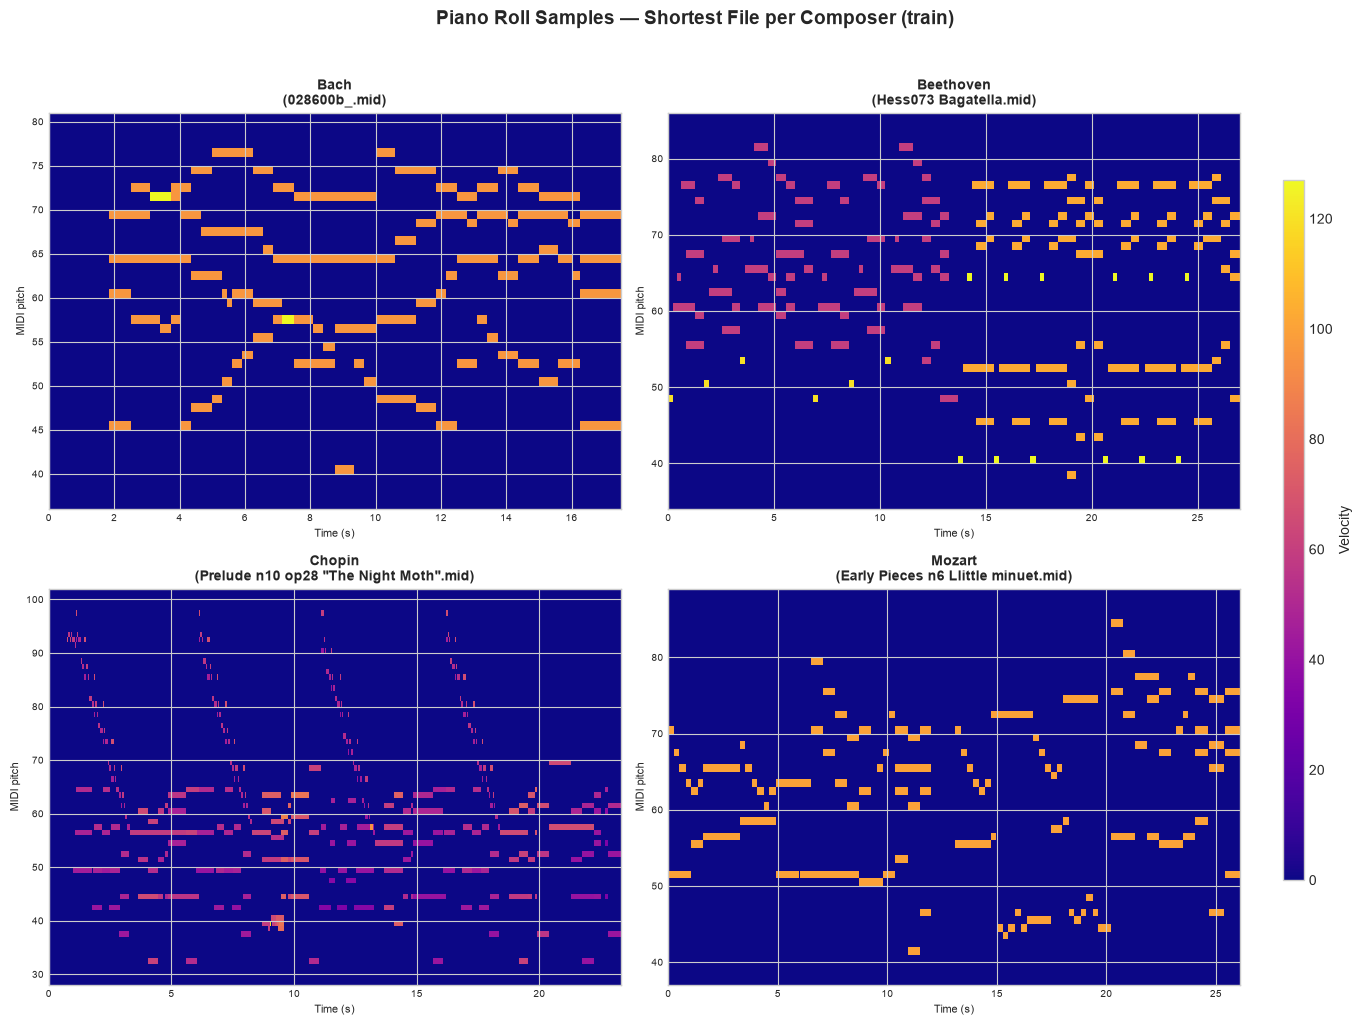

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cmap = plt.cm.plasma

for idx, composer in enumerate(COMPOSERS):
    comp_rows = train[train['composer'] == composer]
    shortest  = comp_rows.nsmallest(1, 'duration_s').iloc[0]
    midi_path = DATA_ROOT / 'train' / composer / shortest['file']

    pm   = pretty_midi.PrettyMIDI(str(midi_path))
    roll = pm.get_piano_roll(fs=20)   # shape: (128, T)

    active = np.any(roll > 0, axis=1)
    if active.any():
        lo = max(0,   int(np.where(active)[0][0])  - 4)
        hi = min(127, int(np.where(active)[0][-1]) + 4)
    else:
        lo, hi = 21, 108

    ax  = axes[idx]
    img = ax.imshow(
        roll[lo:hi+1], aspect='auto', origin='lower',
        cmap=cmap, interpolation='nearest',
        extent=[0, pm.get_end_time(), lo, hi + 1],
        vmin=0, vmax=127,
    )
    ax.set_title(f'{composer}\n({shortest["file"]})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('MIDI pitch', fontsize=8)
    ax.tick_params(labelsize=7)

# Hide unused subplot
for idx in range(len(COMPOSERS), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Piano Roll Samples — Shortest File per Composer (train)',
             fontsize=14, fontweight='bold', y=1.02)

# Tight layout first, then reserve space on the right for a single colorbar
plt.tight_layout(rect=[0, 0, 0.90, 1])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
fig.colorbar(img, cax=cbar_ax, label='Velocity')

plt.savefig(FIGURES_DIR / 'piano_rolls.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Pitch Distribution

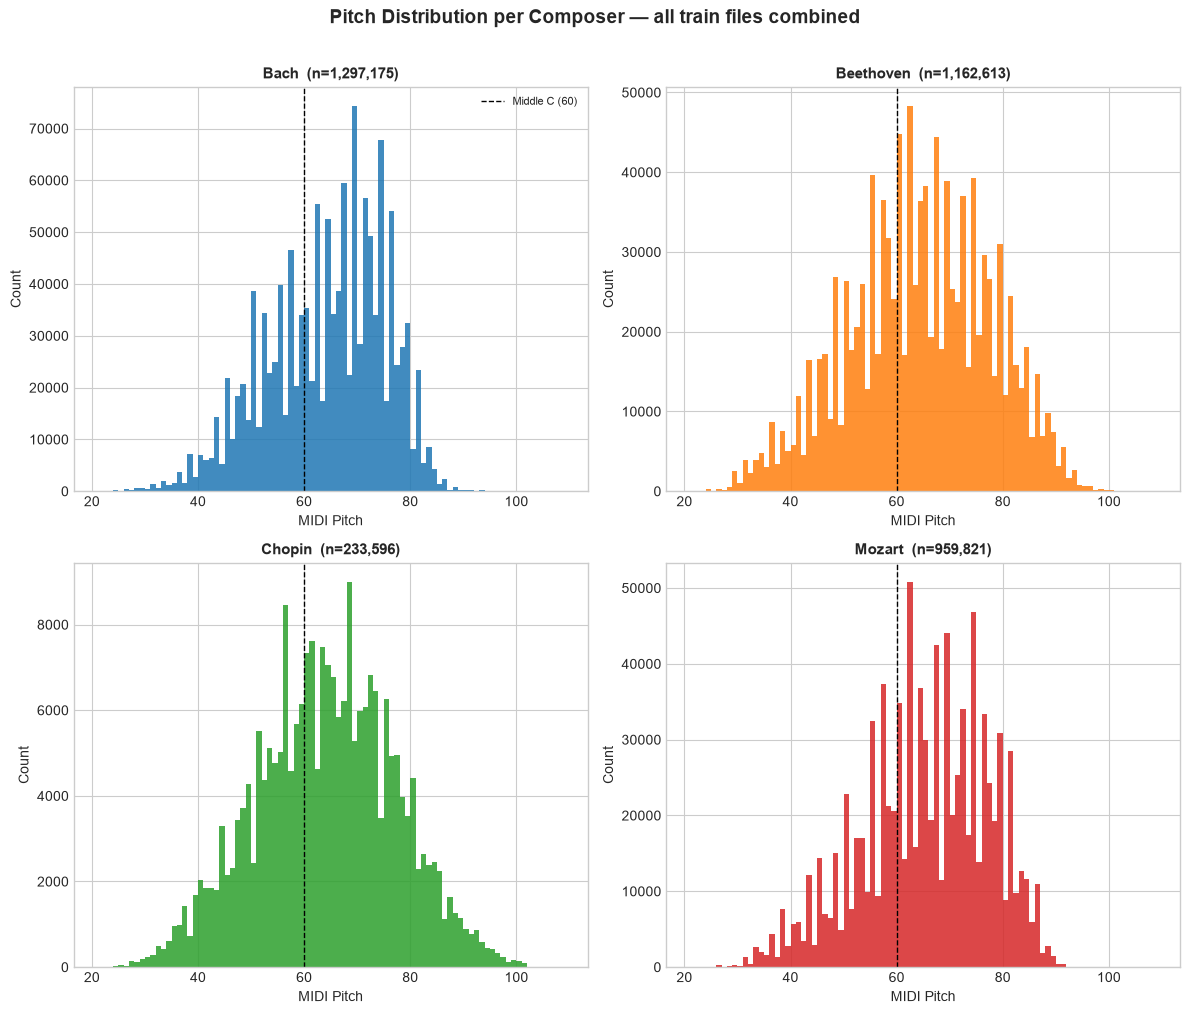

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes   = axes.flatten()
colors = plt.cm.tab10.colors

for idx, composer in enumerate(COMPOSERS):
    comp_rows  = train[train['composer'] == composer]
    all_pitches = []
    for _, row in comp_rows.iterrows():
        midi_path = DATA_ROOT / 'train' / composer / row['file']
        try:
            pm = pretty_midi.PrettyMIDI(str(midi_path))
            pitches = [n.pitch for inst in pm.instruments
                       if not inst.is_drum for n in inst.notes]
            all_pitches.extend(pitches)
        except Exception:
            pass

    ax = axes[idx]
    ax.hist(all_pitches, bins=88, range=(21, 109),
            color=colors[idx % 10], alpha=0.85, edgecolor='none')
    ax.axvline(60, color='black', linestyle='--', linewidth=1, label='Middle C (60)')
    ax.set_title(f'{composer}  (n={len(all_pitches):,})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('MIDI Pitch')
    ax.set_ylabel('Count')
    if idx == 0:
        ax.legend(fontsize=8)

# Hide unused subplot
for idx in range(len(COMPOSERS), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Pitch Distribution per Composer — all train files combined',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pitch_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Pitch Range and Mean Pitch

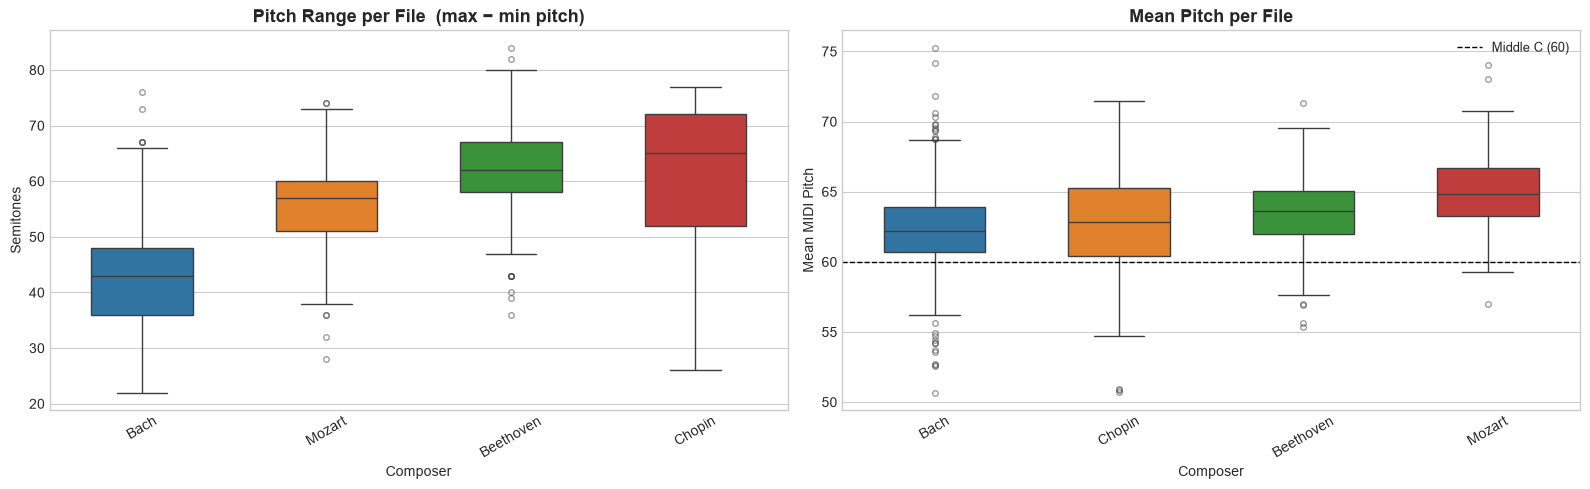

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_pr = train.groupby('composer')['pitch_range'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='pitch_range', order=order_pr,
            palette='tab10', ax=axes[0], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[0].set_title('Pitch Range per File  (max − min pitch)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Composer')
axes[0].set_ylabel('Semitones')
axes[0].tick_params(axis='x', rotation=30)

order_mp = train.groupby('composer')['mean_pitch'].median().sort_values().index
sns.boxplot(data=train, x='composer', y='mean_pitch', order=order_mp,
            palette='tab10', ax=axes[1], width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
axes[1].axhline(60, color='black', linestyle='--', linewidth=1, label='Middle C (60)')
axes[1].set_title('Mean Pitch per File', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Composer')
axes[1].set_ylabel('Mean MIDI Pitch')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pitch_range.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Feature Heatmap

Normalized mean values per composer. Raw values are annotated inside each cell.
This gives a quick at-a-glance view of which features distinguish composers.


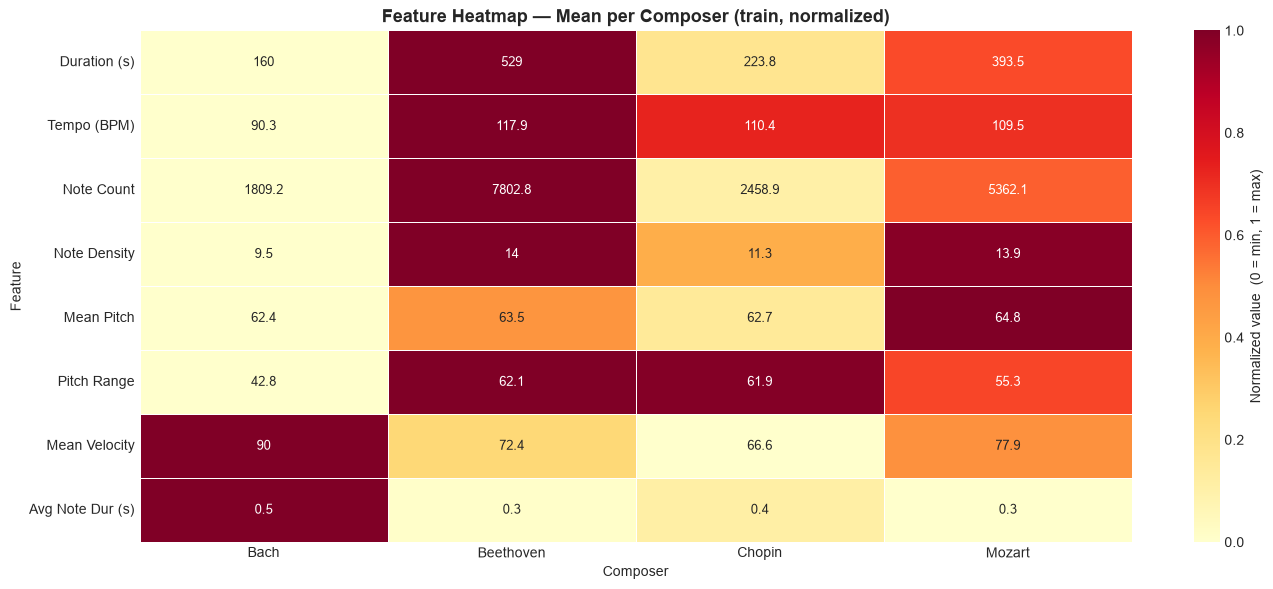

In [14]:
features = ['duration_s', 'avg_tempo_bpm', 'n_notes', 'note_density',
            'mean_pitch', 'pitch_range', 'mean_velocity', 'mean_note_dur_s']
labels   = ['Duration (s)', 'Tempo (BPM)', 'Note Count', 'Note Density',
            'Mean Pitch', 'Pitch Range', 'Mean Velocity', 'Avg Note Dur (s)']

comp_means = train.groupby('composer')[features].mean()
comp_norm  = (comp_means - comp_means.min()) / (comp_means.max() - comp_means.min())
comp_norm.columns  = labels
comp_annot = comp_means.copy()
comp_annot.columns = labels

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    comp_norm.T, annot=comp_annot.T.round(1), fmt='g',
    cmap='YlOrRd', ax=ax, linewidths=0.4,
    cbar_kws={'label': 'Normalized value  (0 = min, 1 = max)'},
    annot_kws={'size': 9},
)
ax.set_title('Feature Heatmap — Mean per Composer (train, normalized)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composer')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Summary Statistics (train split)

In [15]:
summary = train.groupby('composer').agg(
    Files          =('file',            'count'),
    Duration_mean  =('duration_s',      'mean'),
    Duration_std   =('duration_s',      'std'),
    Tempo_BPM      =('avg_tempo_bpm',   'mean'),
    Notes_per_file =('n_notes',         'mean'),
    Note_density   =('note_density',    'mean'),
    Mean_pitch     =('mean_pitch',      'mean'),
    Pitch_range    =('pitch_range',     'mean'),
    Mean_velocity  =('mean_velocity',   'mean'),
).round(1)

summary.columns = [
    'Files', 'Duration (s)', 'Dur std',
    'Tempo (BPM)', 'Notes/file', 'Note density',
    'Mean pitch', 'Pitch range', 'Velocity',
]
summary


,Files,Duration (s),Dur std,Tempo (BPM),Notes/file,Note density,Mean pitch,Pitch range,Velocity
composer,,,,,,,,,
Bach,717,160.0,270.5,90.3,1809.2,9.5,62.4,42.8,90.0
Beethoven,149,529.0,527.4,117.9,7802.8,14.0,63.5,62.1,72.4
Chopin,95,223.8,193.4,110.4,2458.9,11.3,62.7,61.9,66.6
Mozart,179,393.5,261.9,109.5,5362.1,13.9,64.8,55.3,77.9


## 11. Key Takeaways

### Dataset Source
The raw MIDI files come from the Kaggle dataset *MIDI Classic Music* (Blanderbuss, 2025) at <https://www.kaggle.com/datasets/blanderbuss/midi-classic-music>. The project uses only the four required composers: **Bach, Beethoven, Chopin, and Mozart**.

### Class Balance
The filtered dataset is **imbalanced**: Bach dominates (~700 train files), while Chopin has fewer than 100 train files. This will be addressed in modeling by:
- Using **class weights** in the cross-entropy loss,
- Applying **pitch-shift / time-stretch data augmentation** to the smaller classes,
- Reporting per-class precision/recall and a confusion matrix.

### Distinguishing Signals
| Feature | Observation |
|---------|-------------|
| **Note density** | Varies noticeably — useful discriminator between composers |
| **Pitch range** | Bach (Baroque counterpoint) vs. Chopin (Romantic piano writing) differ strongly |
| **Mean pitch** | Differs across eras and instrument idioms |
| **Tempo** | Many files default to 120 BPM — may not be reliable as a standalone feature |
| **Duration** | High variance within each composer — must normalize for model input |
| **Velocity** | Heavily quantized (often constant 127); unlikely to help on its own |
| **Note duration** | Distribution shape differs by composer; adds rhythmic signal |

### Feature Relationships
- Strong positive correlation expected between `n_notes` and `duration_s`;
  `note_density` removes that scale dependence and is a cleaner discriminator.
- PCA shows modest overlap between composers, so raw statistical features alone
  may be insufficient; sequence / spectrogram representations should add value.

### Modelling Implications
| Aspect | Decision |
|--------|----------|
| Piano roll `(128, T)` → CNN | Crop / resize to fixed T (e.g., 500 frames at 20 fps = 25 s) |
| Note sequence → LSTM | Encode pitch as integer; truncate/pad to fixed length L |
| 4-class output | Softmax layer + categorical cross-entropy |
| Imbalanced training set | Class-weighted loss + data augmentation for minority classes |


## 12. Feature Correlations

Pairwise correlations among the engineered features help identify redundancy
and guide feature selection for the classifier.


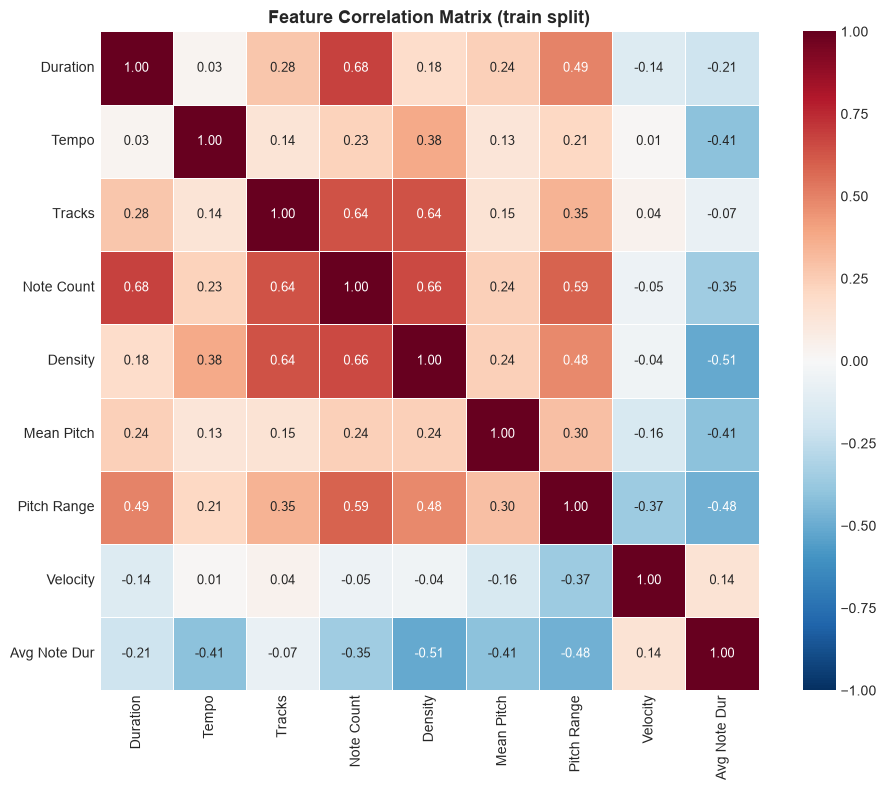

In [16]:
features = ['duration_s', 'avg_tempo_bpm', 'n_tracks', 'n_notes',
            'note_density', 'mean_pitch', 'pitch_range', 'mean_velocity',
            'mean_note_dur_s']
labels   = ['Duration', 'Tempo', 'Tracks', 'Note Count', 'Density',
            'Mean Pitch', 'Pitch Range', 'Velocity', 'Avg Note Dur']

corr = train[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.4, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (train split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Class Separability (PCA)

Project the engineered features onto the first two principal components to
visualize whether composers form any natural clusters.


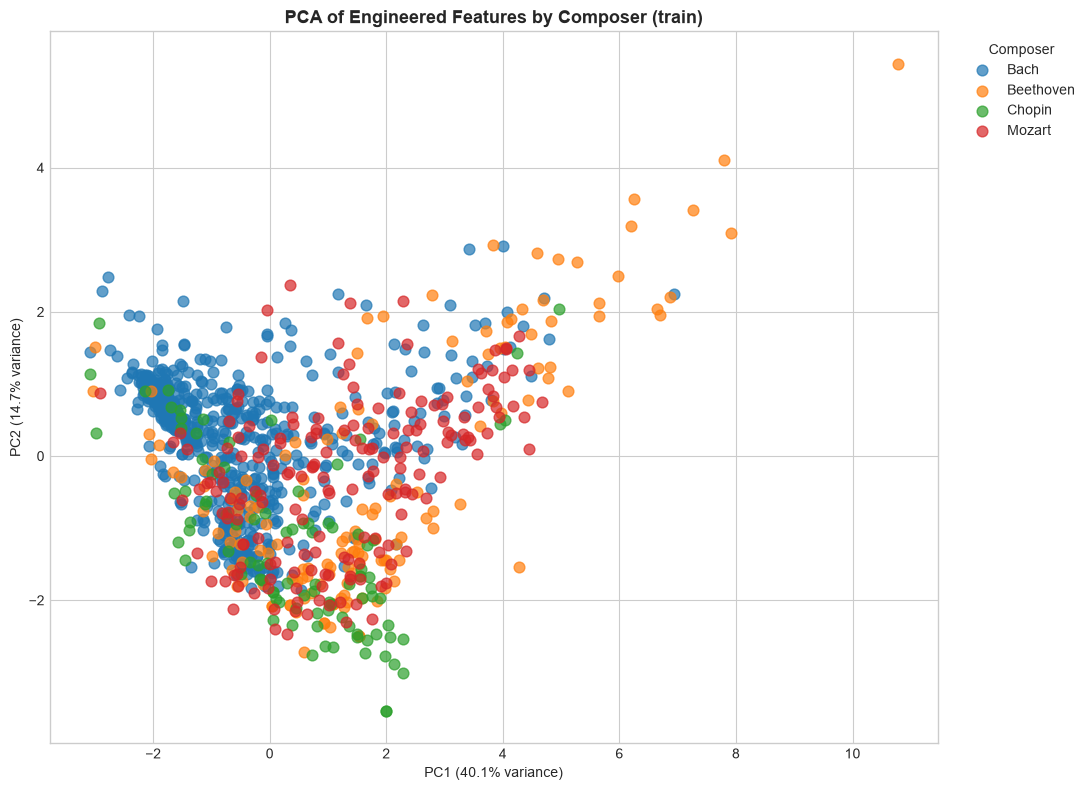

Explained variance ratio: [0.401 0.147]


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = train[features].fillna(train[features].median())
y = train['composer']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
for idx, composer in enumerate(COMPOSERS):
    mask = y == composer
    ax.scatter(pcs[mask, 0], pcs[mask, 1],
               label=composer.capitalize(), alpha=0.7, s=60,
               color=plt.cm.tab10(idx))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of Engineered Features by Composer (train)', fontsize=13, fontweight='bold')
ax.legend(title='Composer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))


## 14. Note Duration Distribution

Rhythmic texture varies by composer and era. Here we pool every note duration
in the train split and compare the log-scaled distributions.


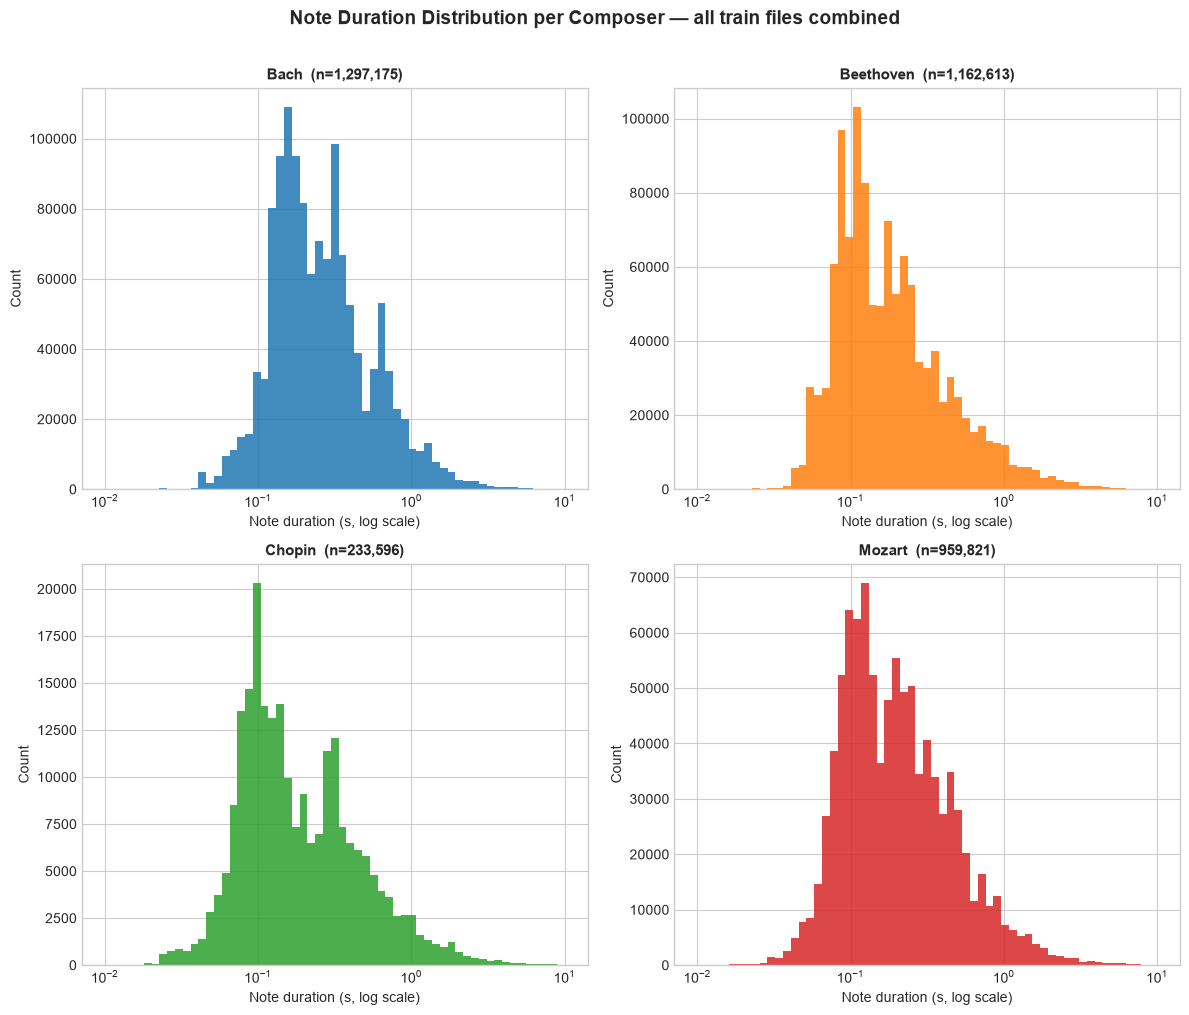

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, composer in enumerate(COMPOSERS):
    comp_rows = train[train['composer'] == composer]
    all_durs = []
    for _, row in comp_rows.iterrows():
        midi_path = DATA_ROOT / 'train' / composer / row['file']
        try:
            pm = pretty_midi.PrettyMIDI(str(midi_path))
            durs = [n.end - n.start for inst in pm.instruments
                    if not inst.is_drum for n in inst.notes]
            all_durs.extend(durs)
        except Exception:
            pass

    ax = axes[idx]
    # Log-scale bins, clip extreme tails for visibility
    durs_arr = np.array(all_durs)
    durs_arr = durs_arr[durs_arr > 0]
    log_bins = np.logspace(np.log10(max(durs_arr.min(), 0.01)),
                           np.log10(min(durs_arr.max(), 10)), 60)
    ax.hist(durs_arr, bins=log_bins, color=plt.cm.tab10(idx),
            alpha=0.85, edgecolor='none')
    ax.set_xscale('log')
    ax.set_title(f'{composer}  (n={len(durs_arr):,})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Note duration (s, log scale)')
    ax.set_ylabel('Count')

# Hide unused subplot
for idx in range(len(COMPOSERS), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Note Duration Distribution per Composer — all train files combined',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'note_duration_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
